# ResNet-18 复现：Fashion-MNIST 教学案例

**知识点简介**：
ResNet（残差网络）通过“残差连接（skip connection）”缓解深层网络的梯度消失与退化问题，让网络在加深后依然容易优化。ResNet-18 是最经典、易上手的版本之一，非常适合教学和入门实践。

**设计意义**：
本案例通过在 Fashion-MNIST 上复现 ResNet-18，帮助学生理解残差结构的动机与实现方式，掌握完整的深度学习训练流程：数据准备 → 模型搭建 → 训练评估 → 结果分析。

## 1. 实验目标与数据路径

- 数据集：Fashion-MNIST（10 类灰度图，28×28）
- 数据下载位置：D:\xiangmu\18-Resnet\data
- 目标：完成 ResNet-18 的训练与评估，并展示关键中间结果（数据规模、模型参数量、训练曲线与预测示例）

In [5]:
from pathlib import Path
import os
import random
import numpy as np
import torch

# 固定随机种子，便于复现
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# 设备与数据路径
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = Path(r"D:\xiangmu\18-Resnet\data")
data_dir.mkdir(parents=True, exist_ok=True)

print("Using device:", device)
print("Data dir:", data_dir)

Using device: cpu
Data dir: D:\xiangmu\18-Resnet\data


## 2. 导入依赖

本案例使用 PyTorch 与 torchvision 完成模型与数据处理，matplotlib 用于可视化，tqdm 展示训练进度。

In [6]:
import sys

for m in list(sys.modules):
    if m.startswith("PIL"):
        del sys.modules[m]

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams["figure.dpi"] = 120

## 3. 数据加载与可视化

Fashion-MNIST 为 28×28 灰度图像，这里进行标准化并构建 DataLoader。随后展示一个 batch 的图像与标签，便于理解输入形状与类别分布。

Train size: 60000
Test size: 10000
Batch images shape: torch.Size([128, 1, 28, 28])
Batch labels shape: torch.Size([128])


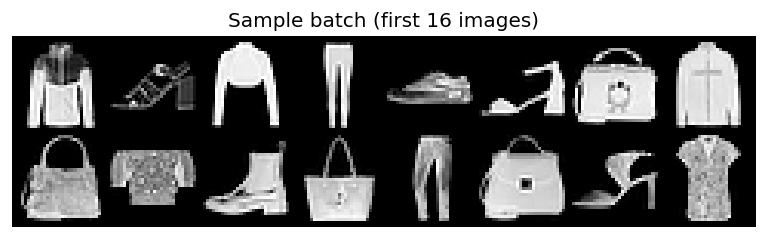

Sample labels: ['Coat', 'Sandal', 'Coat', 'Trouser', 'Sneaker', 'Sandal', 'Bag', 'Coat', 'Bag', 'Shirt', 'Ankle boot', 'Bag', 'Trouser', 'Bag', 'Sandal', 'Shirt']
样本标签： ['外套', '凉鞋', '外套', '裤子', '运动鞋', '凉鞋', '包', '外套', '包', '衬衫', '短靴', '包', '裤子', '包', '凉鞋', '衬衫']


In [13]:
import warnings
import os

warnings.filterwarnings('ignore')  # 屏蔽警告
os.environ['TORCHVISION_DATASETS_DOWNLOAD_PROGRESS'] = '0'  # 关闭PyTorch数据集下载进度条
batch_size = 128
num_workers = 0  # Windows 下建议使用 0

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root=data_dir, train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root=data_dir, train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

classes = train_dataset.classes

# 展示一个 batch
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)

grid = make_grid(images[:16], nrow=8, padding=2, normalize=True)
plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Sample batch (first 16 images)")
plt.show()

print("Sample labels:", [classes[i] for i in labels[:16]])
class_names = [
    'T恤/上衣', '裤子', '套头衫', '连衣裙', '外套',
    '凉鞋', '衬衫', '运动鞋', '包', '短靴'
]
# 替换原打印标签的代码：
print("样本标签：", [class_names[i] for i in labels[:16]])

## 4. 构建 ResNet-18（适配 28×28 灰度图）

为适配小尺寸灰度图像，做两点轻微调整：
1. 输入通道从 3 改为 1。
2. 去掉最初的 7×7 卷积与最大池化，改为 3×3 卷积与更温和的下采样。

In [8]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet18Small(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64

        # 适配 28×28 灰度图
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride=stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = ResNet18Small(num_classes=10).to(device)
print(model)
print("Trainable parameters:", count_parameters(model))

ResNet18Small(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bi

## 5. 训练与评估

使用交叉熵损失与 Adam 优化器进行训练，并在每个 epoch 结束后评估测试集准确率。

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 3

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}"
    )

Epoch 01 | Train Loss: 0.3704 Acc: 0.8648 | Test Loss: 0.2913 Acc: 0.8937


Epoch 02 | Train Loss: 0.2331 Acc: 0.9141 | Test Loss: 0.2495 Acc: 0.9111


Epoch 03 | Train Loss: 0.1889 Acc: 0.9305 | Test Loss: 0.2279 Acc: 0.9174


## 6. 结果可视化与预测示例

绘制训练/测试曲线，并展示部分预测结果，帮助直观理解模型表现。

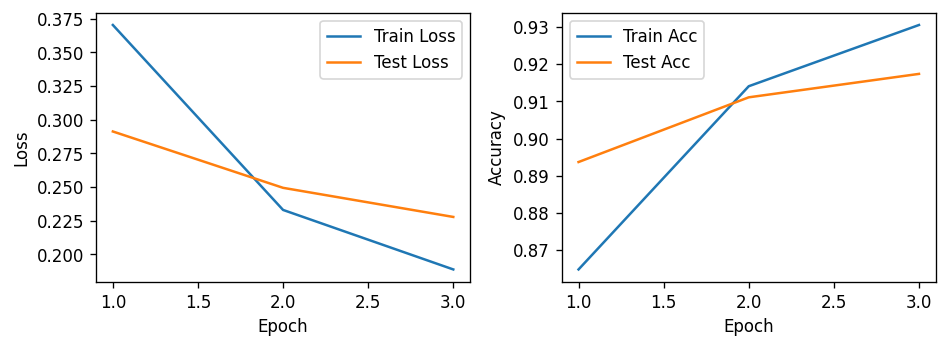

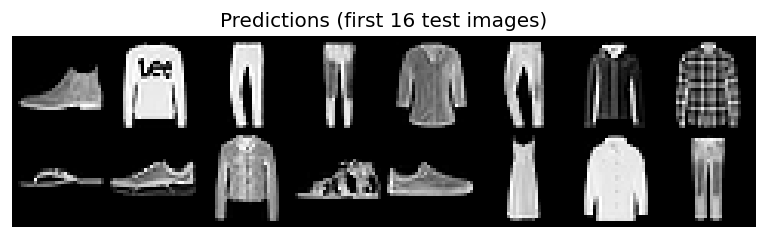

GT: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker', 'Coat', 'Sandal', 'Sneaker', 'Dress', 'Coat', 'Trouser']
PR: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker', 'Coat', 'Sandal', 'Sandal', 'Dress', 'Coat', 'Trouser']


In [10]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["test_acc"], label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# 预测示例
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

show_images = images[:16].cpu()
show_labels = labels[:16].cpu()
show_preds = preds[:16].cpu()

grid = make_grid(show_images, nrow=8, padding=2, normalize=True)
plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Predictions (first 16 test images)")
plt.show()

print("GT:", [classes[i] for i in show_labels])
print("PR:", [classes[i] for i in show_preds])

## 7. 小结

本案例完成了 ResNet-18 在 Fashion-MNIST 上的端到端复现，重点理解了残差连接在深层网络中的作用，并通过训练曲线与预测示例观察了模型性能。

## 8. 拓展与思考（含解答思路）

1. **更深的网络会更好吗？**
   - 思路：将每个 stage 的 block 数量从 `[2,2,2,2]` 增加为 `[3,4,6,3]`，对比参数量、训练时间与准确率变化。

2. **数据增强是否能提升泛化？**
   - 思路：在 `transforms` 中加入随机裁剪、水平翻转，比较测试集准确率与过拟合现象。

3. **优化器与学习率策略的影响**
   - 思路：将 Adam 替换为 SGD + momentum，并加入学习率衰减（如 StepLR），观察收敛速度与最终性能。

4. **结构改动：在残差块中加入 Dropout 是否有效？**
   - 思路：在 `BasicBlock` 中加入 Dropout，观察训练/测试曲线是否更稳定，是否减少过拟合。

5. **可解释性：哪些类别最容易混淆？**
   - 思路：统计混淆矩阵，定位容易混淆的类别（例如 “Shirt” 与 “T-shirt”），并分析原因。